In [8]:
# ============================================================
# 데이터 준비 — 캐시 있으면 로드(수 초), 없으면 빌드 후 저장(~7분)
#   ※ 이 셀을 쓰면 아래 로드·전처리·벡터화 셀(cell-00~cell-14)은 실행하지 말 것
# ============================================================
# ============================================================
# 사용법

# 첫 실행 (한 번만):
# 1. 이 셀 실행 → cache/ 폴더에 .npz 8개 + mercari_df.pkl 저장 (~7분)

# 그다음부터 (커널 재시작 후):
# 1. import 셀 (numpy, xgboost, optuna, Ridge, LGBMRegressor 등)
# 2. 이 셀 → 몇 초 만에 로드
# 3. rmsle / evaluate_org_price / model_train_predict 함수 정의 셀
# 4. 바로 모델링 셀 (dec7dc60 셀1 → 셀2 Ridge → …)

# → cell-00~cell-14 (로드·전처리·벡터화·EDA 그림)는 건너뜁니다. 특히 cell-03(np.log1p)을 다시 돌리면 이중 변환되니 주의.

# 참고
# - 전처리 로직(split_cat·fillna·max_features 등)을 바꾸면 → cache/ 폴더 삭제 후 이 셀 재실행
# - 용량: .npz 8개 합쳐 ~700MB, pkl ~200MB
# - EDA 그림이 필요하면 그때만 viz 셀들 따로 실행 (모델링엔 불필요)
# - mercari_df는 parquet 대신 pickle로 캐싱 (pandas 3.x + 최신 pyarrow 조합에서
#   ArrowKeyError('arrow.py_extension_type')가 나는 이슈 회피 — 내부 캐시 용도라 pickle로 충분)
# ============================================================
import os, numpy as np, pandas as pd, scipy.sparse as sp
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelBinarizer

CACHE  = r"C:\big21\ml-dev\chap08\cache"
_NAMES = ['X_name','X_descp','X_brand','X_item_cond_id','X_shipping',
          'X_cat_dae','X_cat_jung','X_cat_so']
_ready = os.path.isdir(CACHE) and os.path.exists(f"{CACHE}/mercari_df.pkl") \
         and all(os.path.exists(f"{CACHE}/{n}.npz") for n in _NAMES)

if _ready:
    mercari_df = pd.read_pickle(f"{CACHE}/mercari_df.pkl")
    for n in _NAMES:
        globals()[n] = sp.load_npz(f"{CACHE}/{n}.npz")
    print("✅ 캐시 로드 — 벡터화 스킵")
else:
    print("캐시 없음 → 빌드 시작 (~7분)")
    mercari_df = pd.read_csv('../data/mercari_train.tsv', sep='\t')
    mercari_df['price'] = np.log1p(mercari_df['price'])

    def split_cat(c):
        try: return c.split('/')
        except Exception: return ['Other_Null','Other_Null','Other_Null']
    mercari_df['cat_dae'], mercari_df['cat_jung'], mercari_df['cat_so'] = \
        zip(*mercari_df['category_name'].apply(split_cat))
    for c in ['brand_name','category_name','item_description']:
        mercari_df[c] = mercari_df[c].fillna('Other_Null')

    X_name  = TfidfVectorizer(max_features=50000, ngram_range=(1,1),
                              stop_words='english').fit_transform(mercari_df['name'])
    X_descp = TfidfVectorizer(max_features=50000, ngram_range=(1,2),
                              stop_words='english').fit_transform(mercari_df['item_description'])
    _lb = lambda col: LabelBinarizer(sparse_output=True).fit_transform(mercari_df[col])
    X_brand, X_item_cond_id, X_shipping = _lb('brand_name'), _lb('item_condition_id'), _lb('shipping')
    X_cat_dae, X_cat_jung, X_cat_so     = _lb('cat_dae'), _lb('cat_jung'), _lb('cat_so')

    os.makedirs(CACHE, exist_ok=True)
    mercari_df.to_pickle(f"{CACHE}/mercari_df.pkl")
    for n in _NAMES:
        sp.save_npz(f"{CACHE}/{n}.npz", globals()[n].tocsr())
    print("✅ 빌드 + 캐시 저장 완료:", CACHE)

# 이후 모델링 셀들이 쓰는 공통 변수
sparse_matrix_list = (X_descp, X_name, X_brand, X_item_cond_id,
                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so)
y_all = mercari_df['price'].to_numpy()   # 이미 log1p
print("설계행렬:", (len(mercari_df), sum(m.shape[1] for m in sparse_matrix_list)))


✅ 캐시 로드 — 벡터화 스킵
설계행렬: (1482535, 105812)


In [104]:
from sklearn.linear_model import Ridge , LogisticRegression
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.feature_extraction.text import CountVectorizer , TfidfVectorizer
import pandas as pd

mercari_df= pd.read_csv('../data/mercari_train.tsv',sep='\t')
print(mercari_df.shape)
mercari_df.head(3)

(1482535, 8)


,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.000,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & Parts,Razer,52.000,0,This keyboard is in great condition and works like it came out of the box. All of the ports are tested and work perfectly. The lights are customizable via the Razer Synapse app on your PC.
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.000,1,"Adorable top with a hint of lace and a key hole in the back! The pale pink is a 1X, and I also have a 3X available in white!"


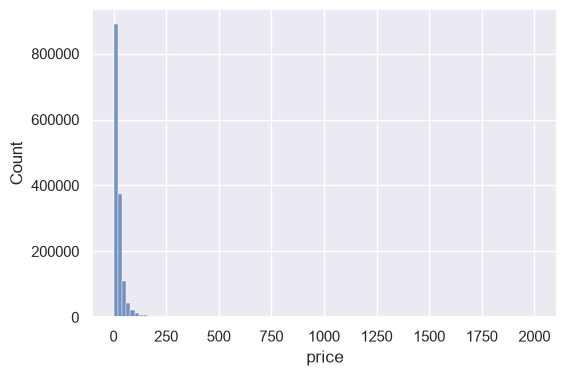

In [105]:
%matplotlib inline
# 가격 분포 확인
import matplotlib.pyplot as plt
import seaborn as sns

y_train_df = mercari_df['price']
plt.figure(figsize=(6,4))
sns.histplot(y_train_df, bins=100)
plt.show()

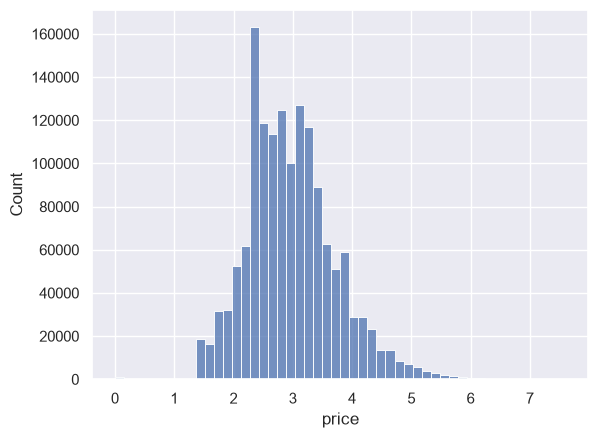

In [106]:
import numpy as np

y_train_df = np.log1p(y_train_df)
sns.histplot(y_train_df, bins=50)
plt.show()

In [107]:
mercari_df['price'] = np.log1p(mercari_df['price'])
mercari_df['price'].head(3)

0   2.398
1   3.970
2   2.398
Name: price, dtype: float64

In [108]:
print('Shipping 값 유형:\n',mercari_df['shipping'].value_counts())
print('item_condition_id 값 유형:\n',mercari_df['item_condition_id'].value_counts())

Shipping 값 유형:
 shipping
0    819435
1    663100
Name: count, dtype: int64
item_condition_id 값 유형:
 item_condition_id
1    640549
3    432161
2    375479
4     31962
5      2384
Name: count, dtype: int64


In [109]:
boolean_cond= mercari_df['item_description']=='No description yet'
mercari_df[boolean_cond]['item_description'].count()

np.int64(82489)

In [110]:
# apply lambda에서 호출되는 대,중,소 분할 함수 생성, 대,중,소 값을 리스트 반환
def split_cat(category_name):
    try:
        return category_name.split('/')
    except:
        return ['Other_Null' , 'Other_Null' , 'Other_Null']

# 위의 split_cat( )을 apply lambda에서 호출하여 대,중,소 컬럼을 mercari_df에 생성.
mercari_df['cat_dae'], mercari_df['cat_jung'], mercari_df['cat_so'] = \
                        zip(*mercari_df['category_name'].apply(lambda x : split_cat(x)))

# 대분류만 값의 유형과 건수를 살펴보고, 중분류, 소분류는 값의 유형이 많으므로 분류 갯수만 추출
print('대분류 유형 :\n', mercari_df['cat_dae'].value_counts())
print('중분류 갯수 :', mercari_df['cat_jung'].nunique())
print('소분류 갯수 :', mercari_df['cat_so'].nunique())

대분류 유형 :
 cat_dae
Women                     664385
Beauty                    207828
Kids                      171689
Electronics               122690
Men                        93680
Home                       67871
Vintage & Collectibles     46530
Other                      45351
Handmade                   30842
Sports & Outdoors          25342
Other_Null                  6327
Name: count, dtype: int64
중분류 갯수 : 114
소분류 갯수 : 871


In [111]:
mercari_df['brand_name'] = mercari_df['brand_name'].fillna(value='Other_Null')
mercari_df['category_name'] = mercari_df['category_name'].fillna(value='Other_Null')
mercari_df['item_description'] = mercari_df['item_description'].fillna(value='Other_Null')

# 각 컬럼별로 Null값 건수 확인. 모두 0가 나와야 합니다.
mercari_df.isnull().sum()

train_id             0
name                 0
item_condition_id    0
category_name        0
brand_name           0
price                0
shipping             0
item_description     0
cat_dae              0
cat_jung             0
cat_so               0
dtype: int64

## EDA 시각화

전처리를 마친 `mercari_df`(가격은 `log1p` 변환 상태)를 대상으로 주요 변수의 분포와
가격과의 관계를 살펴본다. 브랜드/카테고리 결측치는 `Other_Null` 로 채워진 상태다.


In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

# 상위 10개 브랜드(Other_Null 제외) — 이후 여러 그래프에서 재사용
_bcnt = mercari_df['brand_name'].value_counts()
top10_brands = _bcnt[_bcnt.index != 'Other_Null'].index[:10].tolist()
top10_brands

['PINK',
 'Nike',
 "Victoria's Secret",
 'LuLaRoe',
 'Apple',
 'FOREVER 21',
 'Nintendo',
 'Lululemon',
 'Michael Kors',
 'American Eagle']

### 1. 상품 상태(item_condition_id) 분포

개수 대 품목 상태 히스토그램. 상당수의 제품이 양호하거나 새 제품 상태(1~3)임을 알 수 있습니다.


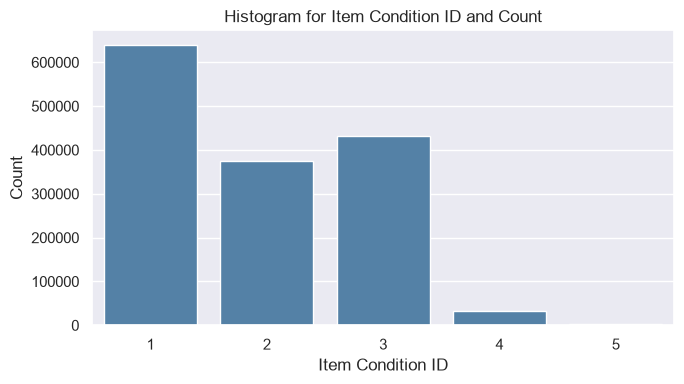

In [113]:
plt.figure(figsize=(7, 4))
sns.countplot(x='item_condition_id', data=mercari_df, color='steelblue')
plt.title('Histogram for Item Condition ID and Count')
plt.xlabel('Item Condition ID'); plt.ylabel('Count')
plt.tight_layout(); plt.show()

### 2. 상품 상태별 로그 가격 (박스플롯)

박스 플롯은 가격과 상품 상태의 변동을 보여주며, 보시다시피 변동폭은 미미합니다. 다만 상품 상태 ID가
5인 상품의 가격이 다른 상품보다 높은 것을 확인할 수 있는데, 이는 메르카리 마켓플레이스에 골동품이
포함되어 있음을 시사하는 것일 수 있습니다.


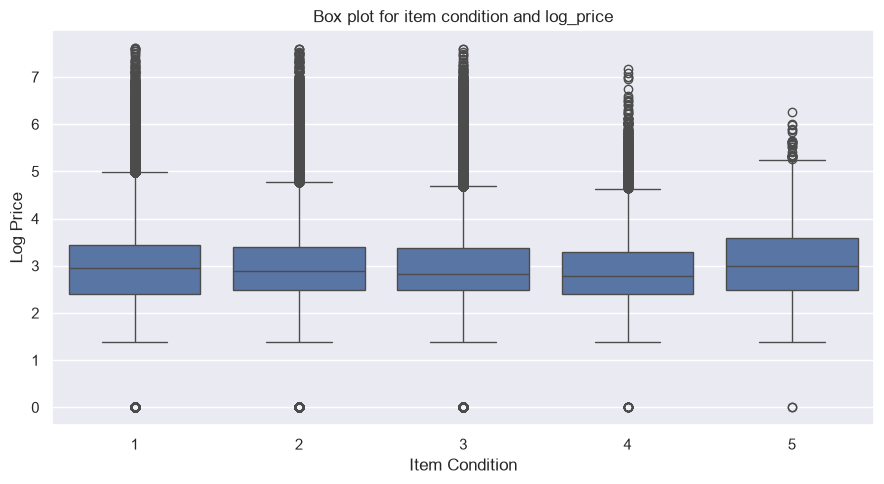

In [114]:
plt.figure(figsize=(9, 5))
sns.boxplot(x='item_condition_id', y='price', data=mercari_df)
plt.title('Box plot for item condition and log_price')
plt.xlabel('Item Condition'); plt.ylabel('Log Price')
plt.tight_layout(); plt.show()
# 147만 행 박스플롯이라 10~30초 소요될 수 있음

### 3. 등장 빈도 상위 10개 브랜드

상위 10개 브랜드 히스토그램(`Other_Null` 제외). PINK, Nike 등이 가장 많이 등장하며, 한 번만
등장하는 브랜드도 매우 많아 꼬리가 긴 분포를 이룹니다.


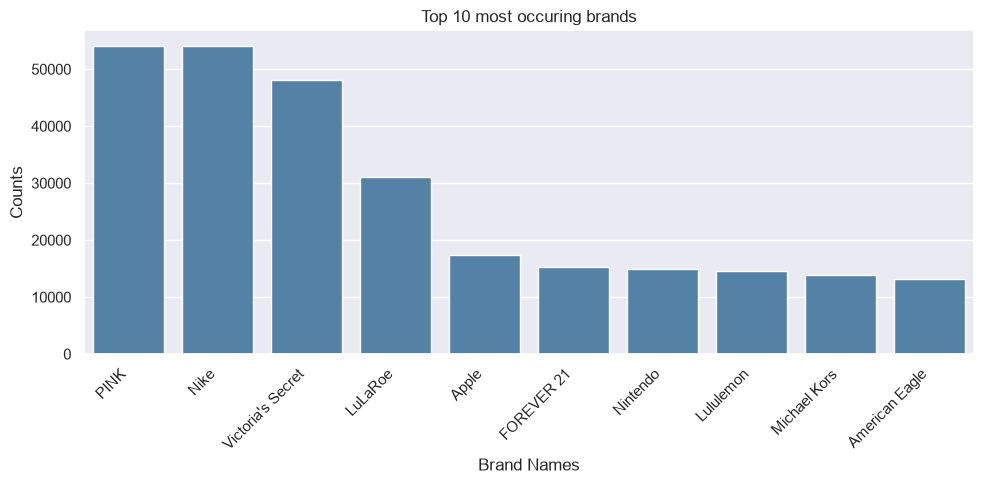

In [115]:
top10_cnt = _bcnt[_bcnt.index != 'Other_Null'][:10]
plt.figure(figsize=(10, 5))
sns.barplot(x=top10_cnt.index, y=top10_cnt.values, color='steelblue')
plt.title('Top 10 most occuring brands')
plt.xlabel('Brand Names'); plt.ylabel('Counts')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

### 4. 상위 10개 브랜드의 중간 가격

상위 브랜드 대부분의 중간 가격이 전체 중간가(빨간 기준선, $17)보다 높습니다. 특히 Michael Kors, Lululemon, LuLaRoe 는 전체보다 뚜렷하게 높은 중간 가격을 가집니다. 반면 American Eagle·FOREVER 21은 오히려 전체 중간가보다 낮습니다.

In [ ]:
# 상위 10개 브랜드의 중간 가격 — 실제 달러, 내림차순 정렬 + 전체 중간가 기준선
med = (mercari_df[mercari_df['brand_name'].isin(top10_brands)]
       .groupby('brand_name')['price'].median())
med = np.expm1(med).sort_values(ascending=False)          # log1p -> $, 내림차순
overall = np.expm1(mercari_df['price'].median())          # 전체 중간가

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=med.index, y=med.values, color='steelblue')
ax.axhline(overall, color='crimson', ls='--', lw=1.6)
ax.text(len(med) * 0.62, overall + med.max() * 0.13, f'전체 중간가 ${overall:,.0f}',
        color='crimson', ha='center', va='bottom', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='crimson', lw=1))
for i, v in enumerate(med.values):
    ax.text(i, v + med.max() * 0.015, f'${v:,.0f}', ha='center', va='bottom', fontsize=9)
plt.title('median price by top-10 brand (sorted)')
plt.xlabel('Brand'); plt.ylabel('Median Price ($)')
plt.ylim(0, med.max() * 1.15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()


### 5. 상위 10개 브랜드별 로그 가격 (박스플롯)

Apple 은 판매 가격 변동폭이 큰 반면, FOREVER 21 은 매우 좁은 가격 범위에서 판매되는 것으로
관찰됩니다.


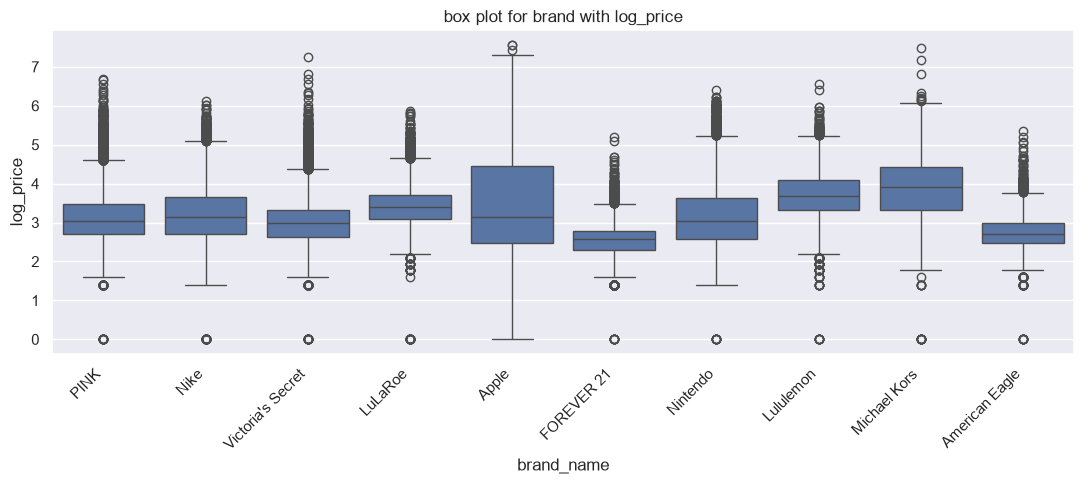

In [117]:
sub = mercari_df[mercari_df['brand_name'].isin(top10_brands)]
plt.figure(figsize=(11, 5))
sns.boxplot(x='brand_name', y='price', data=sub, order=top10_brands)
plt.title('box plot for brand with log_price')
plt.xlabel('brand_name'); plt.ylabel('log_price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

### 6. 가장 비싼 브랜드 Top 50

**과제: 가장 비싼 브랜드와 가장 저렴한 브랜드를 선정하세요.**

브랜드별 평균 가격(원 스케일, `expm1` 로 복원) 기준 상위 50개. 소수의 고가 명품 브랜드가
$2,000 상한 부근에 몰려 있습니다.


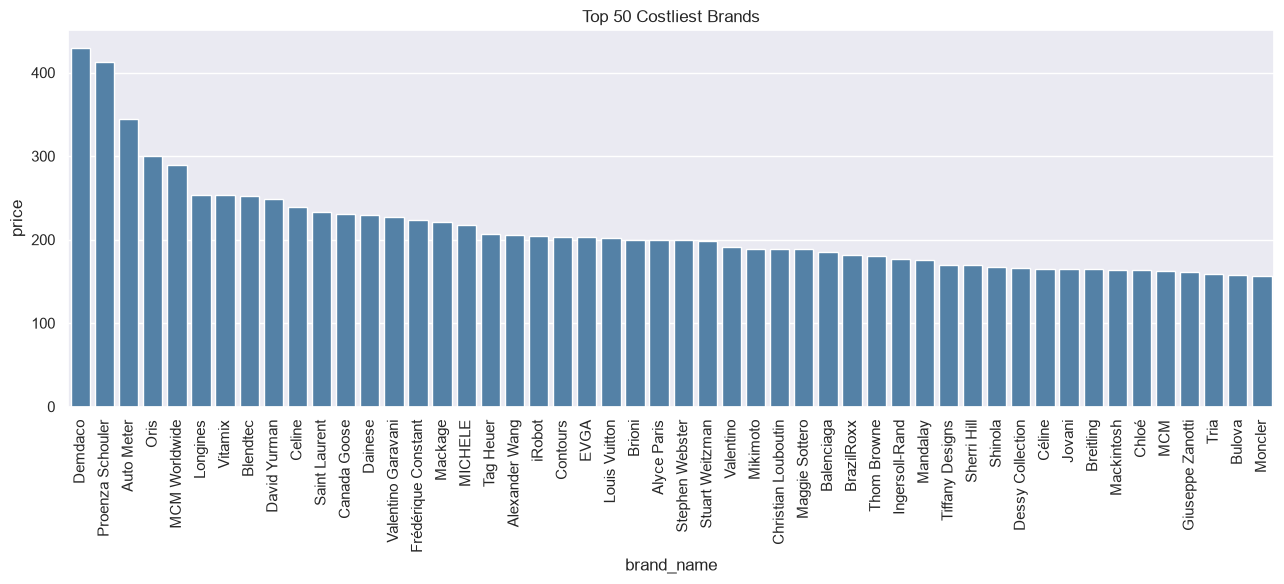

가장 비싼 브랜드 : Demdaco (평균 $429)
가장 저렴한 브랜드 : Gossip Girl (평균 $0.00)


In [118]:
raw_price = np.expm1(mercari_df['price'])
brand_mean = raw_price.groupby(mercari_df['brand_name']).mean()
brand_mean = brand_mean[brand_mean.index != 'Other_Null'].sort_values(ascending=False)[:50]

plt.figure(figsize=(13, 6))
sns.barplot(x=brand_mean.index, y=brand_mean.values, color='steelblue')
plt.title('Top 50 Costliest Brands')
plt.xlabel('brand_name'); plt.ylabel('price')
plt.xticks(rotation=90)
plt.tight_layout(); plt.show()

print('가장 비싼 브랜드 :', brand_mean.index[0], f'(평균 ${brand_mean.iloc[0]:.0f})')
cheap = raw_price.groupby(mercari_df['brand_name']).mean()
cheap = cheap[cheap.index != 'Other_Null'].sort_values()
print('가장 저렴한 브랜드 :', cheap.index[0], f'(평균 ${cheap.iloc[0]:.2f})')

### 7. 대분류 카테고리별 로그 가격 (박스플롯)

**과제: 가격(목표 변수)이 대분류 범주에 미치는 영향을 파악한다.**

전반적인 제품 가격은 변동폭이 크지 않고 비교적 안정적입니다. 남성용(Men) 제품의 중간 가격은 다른
카테고리보다 약간 높으며, 수공예품(Handmade)은 약간 낮습니다. 다만 전자제품(Electronics)·생활용품
(Home) 카테고리는 가격 변동폭이 커서 가격 편차가 큽니다.


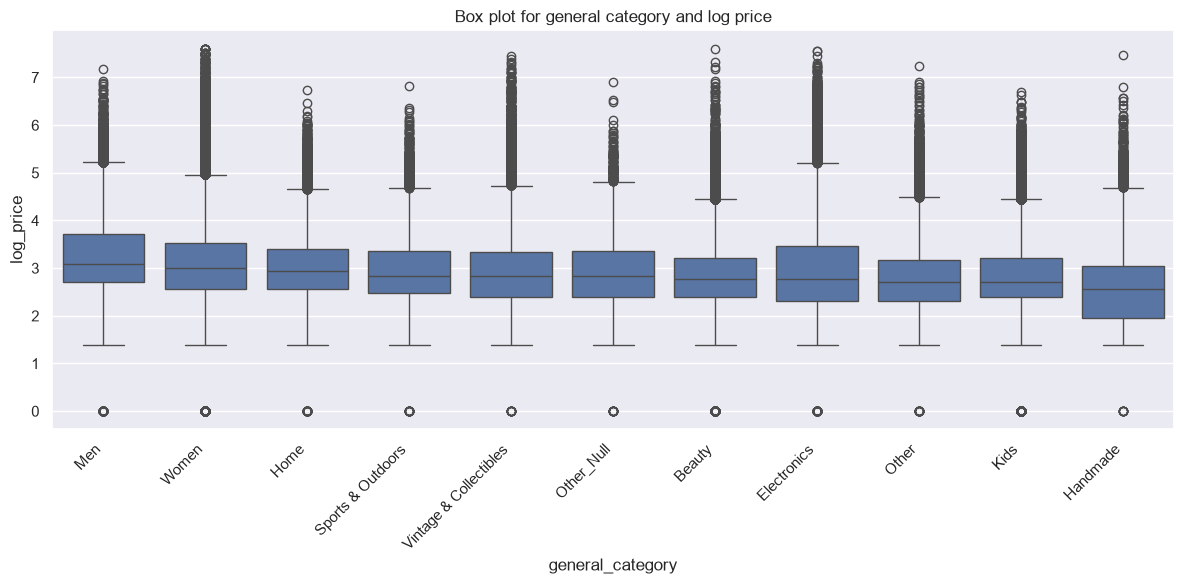

In [119]:
order = (mercari_df.groupby('cat_dae')['price'].median()
         .sort_values(ascending=False).index)
plt.figure(figsize=(12, 6))
sns.boxplot(x='cat_dae', y='price', data=mercari_df, order=order)
plt.title('Box plot for general category and log price')
plt.xlabel('general_category'); plt.ylabel('log_price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

### 8. 상품 설명 길이 vs 로그 가격

제품 설명의 길이와 가격대 사이에 상관관계가 있을까요? 긴 설명이 제품의 인지 가치를 높여 더 높은
가격을 정당화하는지, 아니면 저렴한 제품은 간결한 설명으로 충분한지 확인합니다.

그래프를 보면 설명이 길어질수록 로그 가격이 완만하게 상승하는 경향이 있어, 긴 설명이 더 많은
정보를 제공해 더 높은 가격을 정당화하는 데 도움이 될 수 있음을 시사합니다. 다만 매우 짧은 설명
구간에서도 가격이 낮지만은 않아, 저렴한 상품은 간결한 설명으로 충분한 경우도 있습니다.


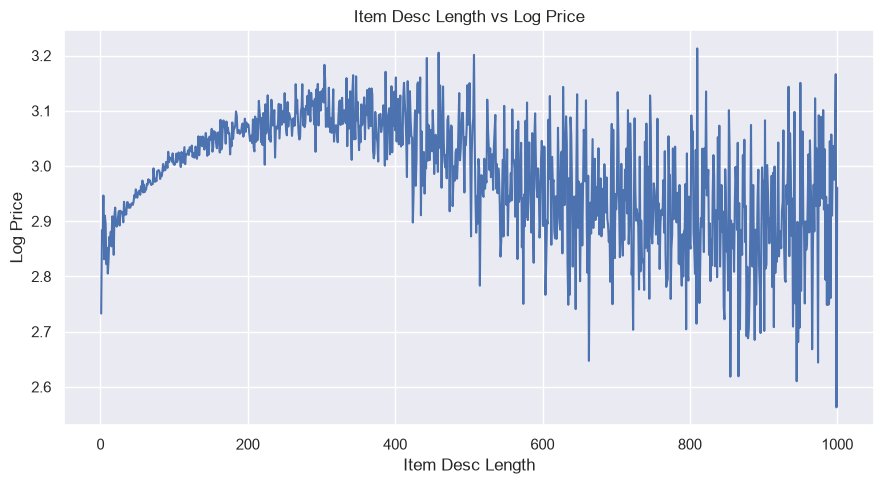

In [120]:
mercari_df['desc_len'] = mercari_df['item_description'].str.len()
_d = mercari_df[mercari_df['desc_len'] <= 1000]

plt.figure(figsize=(9, 5))
sns.lineplot(x='desc_len', y='price', data=_d, errorbar=None)   # 구버전 seaborn이면 ci=None
plt.title('Item Desc Length vs Log Price')
plt.xlabel('Item Desc Length'); plt.ylabel('Log Price')
plt.tight_layout(); plt.show()

#### 특히 선형 회귀의 경우 원-핫 인코딩 적용이 훨씬 선호되므로 인코딩할 피처는 모두 원-핫 인코딩을 적용
#### 피처 벡터화의 경우는 비교적 짧은 텍스트의 경우는 Count 기반의 벡터화를, 긴 텍스트는 TD-IDF기반의 벡터화를 적용

In [121]:
print('brand name 의 유형 건수 :', mercari_df['brand_name'].nunique())
print('brand name sample 5건 : \n', mercari_df['brand_name'].value_counts()[:5])

brand name 의 유형 건수 : 4810
brand name sample 5건 : 
 brand_name
Other_Null           632682
PINK                  54088
Nike                  54043
Victoria's Secret     48036
LuLaRoe               31024
Name: count, dtype: int64


In [122]:
print('name 의 종류 갯수 :', mercari_df['name'].nunique())
print('name sample 7건 : \n', mercari_df['name'][:7])

name 의 종류 갯수 : 1225273
name sample 7건 : 
 0    MLB Cincinnati Reds T Shirt Size XL
1       Razer BlackWidow Chroma Keyboard
2                         AVA-VIV Blouse
3                  Leather Horse Statues
4                   24K GOLD plated rose
5       Bundled items requested for Ruie
6     Acacia pacific tides santorini top
Name: name, dtype: str


In [123]:
pd.set_option('max_colwidth', 200)

# item_description의 평균 문자열 개수
print('item_description 평균 문자열 개수:',mercari_df['item_description'].str.len().mean())

mercari_df['item_description'][:2]

item_description 평균 문자열 개수: 145.71139703278507


0                                                                                                                                                                              No description yet
1    This keyboard is in great condition and works like it came out of the box. All of the ports are tested and work perfectly. The lights are customizable via the Razer Synapse app on your PC.
Name: item_description, dtype: str

In [124]:
# name 속성에 대해 TfidfVectorizer 변환
cnt_vec = TfidfVectorizer(max_features = 50000, ngram_range= (1,1) , stop_words='english')
X_name = cnt_vec.fit_transform(mercari_df.name)

# item_description 에 대해 TfidfVectorizer
tfidf_descp = TfidfVectorizer(max_features = 50000, ngram_range= (1,2) , stop_words='english')
X_descp = tfidf_descp.fit_transform(mercari_df['item_description'])

print('name vectorization shape:',X_name.shape)
print('item_description vectorization shape:',X_descp.shape)
## 3분 소요

name vectorization shape: (1482535, 50000)
item_description vectorization shape: (1482535, 50000)


In [125]:
from sklearn.preprocessing import LabelBinarizer

# brand_name, item_condition_id, shipping 각 피처들을 희소 행렬 원-핫 인코딩 변환 <= 선형 모델에 적합
lb_brand_name= LabelBinarizer(sparse_output=True)
X_brand = lb_brand_name.fit_transform(mercari_df['brand_name'])

lb_item_cond_id = LabelBinarizer(sparse_output=True)
X_item_cond_id = lb_item_cond_id.fit_transform(mercari_df['item_condition_id'])

lb_shipping= LabelBinarizer(sparse_output=True)
X_shipping = lb_shipping.fit_transform(mercari_df['shipping'])

# cat_dae, cat_jung, cat_so 각 피처들을 희소 행렬 원-핫 인코딩 변환
lb_cat_dae = LabelBinarizer(sparse_output=True)
X_cat_dae= lb_cat_dae.fit_transform(mercari_df['cat_dae'])

lb_cat_jung = LabelBinarizer(sparse_output=True)
X_cat_jung = lb_cat_jung.fit_transform(mercari_df['cat_jung'])

lb_cat_so = LabelBinarizer(sparse_output=True)
X_cat_so = lb_cat_so.fit_transform(mercari_df['cat_so'])
## 3분 25초 소요

In [126]:
print(type(X_brand), type(X_item_cond_id), type(X_shipping))
print('X_brand_shape:{0}, X_item_cond_id shape:{1}'.format(X_brand.shape, X_item_cond_id.shape))
print('X_shipping shape:{0}, X_cat_dae shape:{1}'.format(X_shipping.shape, X_cat_dae.shape))
print('X_cat_jung shape:{0}, X_cat_so shape:{1}'.format(X_cat_jung.shape, X_cat_so.shape))

<class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'>
X_brand_shape:(1482535, 4810), X_item_cond_id shape:(1482535, 5)
X_shipping shape:(1482535, 1), X_cat_dae shape:(1482535, 11)
X_cat_jung shape:(1482535, 114), X_cat_so shape:(1482535, 871)


In [127]:
from  scipy.sparse import hstack
import gc

sparse_matrix_list = (X_name, X_descp, X_brand, X_item_cond_id,
            X_shipping, X_cat_dae, X_cat_jung, X_cat_so)

# 사이파이 sparse 모듈의 hstack 함수를 이용하여 앞에서 인코딩과 Vectorization을 수행한 데이터 셋을 모두 결합.
X_features_sparse= hstack(sparse_matrix_list).tocsr()
print(type(X_features_sparse), X_features_sparse.shape)

# 데이터 셋이 메모리를 많이 차지하므로 사용 용도가 끝났으면 바로 메모리에서 삭제.
del X_features_sparse
gc.collect()

<class 'scipy.sparse._csr.csr_matrix'> (1482535, 105812)


3789

In [10]:
def rmsle(y , y_pred):
    # underflow, overflow를 막기 위해 log가 아닌 log1p로 rmsle 계산
    return np.sqrt(np.mean(np.power(np.log1p(y) - np.log1p(y_pred), 2)))

def evaluate_org_price(y_test , preds):
   
    # 원본 데이터는 log1p로 변환되었으므로 exmpm1으로 원복 필요.
    preds_exmpm = np.expm1(preds)
    y_test_exmpm = np.expm1(y_test)
   
    # rmsle로 RMSLE 값 추출
    rmsle_result = rmsle(y_test_exmpm, preds_exmpm)
    return rmsle_result

In [5]:
import gc
from  scipy.sparse import hstack

def model_train_predict(model,matrix_list):
    # scipy.sparse 모듈의 hstack 을 이용하여 sparse matrix 결합
    X= hstack(matrix_list).tocsr()    
   
    X_train, X_test, y_train, y_test=train_test_split(X, mercari_df['price'],
                                                      test_size=0.2, random_state=42)
   
    # 모델 학습 및 예측
    model.fit(X_train , y_train)
    preds = model.predict(X_test)
   
    del X , X_train , X_test , y_train
    gc.collect()
   
    return preds , y_test

### "name(상품명)이 item_description(상품설명)보다 더 중요하다"

In [19]:
# lsqr : 반복적 최소제곱법. sklearn 공식 문서상 "가장 빠르다"고 명시되어 있고 안정적    # 소요시간 : 2분 44초
# sparse_cg : 데이터가 매우 크고(수십만~수백만 row) 병렬 처리가 필요한 경우 대안        # 소요시간 : 2분 36초 << 캐쉬 영향..?
# linear_model = Ridge(solver = "lsqr", fit_intercept=False, random_state=42, alpha=1) 
linear_model = Ridge(solver = "sparse_cg", fit_intercept=False, random_state=42, alpha=1)

sparse_matrix_list = (X_name, X_brand, X_item_cond_id,
                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so)
linear_preds , y_test = model_train_predict(model=linear_model ,matrix_list=sparse_matrix_list)
print('Item Description을 제외했을 때 rmsle 값:', evaluate_org_price(y_test , linear_preds))

sparse_matrix_list = (X_descp, X_name, X_brand, X_item_cond_id,
                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so)
linear_preds , y_test = model_train_predict(model=linear_model , matrix_list=sparse_matrix_list)
print('Item Description을 포함한 rmsle 값:',  evaluate_org_price(y_test ,linear_preds))

sparse_matrix_list = (X_descp, X_brand, X_item_cond_id,
                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so)
linear_preds , y_test = model_train_predict(model=linear_model ,matrix_list=sparse_matrix_list)
print('name(상품명)을 제외했을 때 rmsle 값:', evaluate_org_price(y_test , linear_preds))

sparse_matrix_list = (X_descp, X_name, X_brand, X_item_cond_id,
                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so)
linear_preds , y_test = model_train_predict(model=linear_model , matrix_list=sparse_matrix_list)
print('name(상품명)을 포함한 rmsle 값:',  evaluate_org_price(y_test ,linear_preds))

Item Description을 제외했을 때 rmsle 값: 0.5015339057684496
Item Description을 포함한 rmsle 값: 0.4683936177042647
name(상품명)을 제외했을 때 rmsle 값: 0.5104439194733718
name(상품명)을 포함한 rmsle 값: 0.4683936177042647


In [34]:
# ============================================================
# 셀 1 — 공통 준비 (이 셀 하나만 실행하면 데이터 로드부터 평가 함수까지 다 준비됨)
#   ※ 커널 재시작 후 바로 이 셀부터 실행하면 됨 (cell-00~cell-14, da3a2e7e, cell-15/16 안 돌려도 OK)
# ============================================================
import os, json, numpy as np, pandas as pd, gc
import scipy.sparse as sp
from scipy.sparse import hstack
import lightgbm as lgb
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import LabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK, space_eval
from sklearn.model_selection import train_test_split, cross_val_score

# ---- 데이터 준비: 이미 메모리에 있으면 스킵, 없으면 캐시 로드, 캐시도 없으면 빌드 ----
CACHE  = r"C:\big21\ml-dev\chap08\cache"
_NAMES = ['X_name','X_descp','X_brand','X_item_cond_id','X_shipping',
          'X_cat_dae','X_cat_jung','X_cat_so']

if 'X_descp' in globals():
    print('✅ 이미 메모리에 로드돼 있음 — 스킵')
else:
    _ready = os.path.isdir(CACHE) and os.path.exists(f"{CACHE}/mercari_df.pkl") \
             and all(os.path.exists(f"{CACHE}/{n}.npz") for n in _NAMES)
    if _ready:
        mercari_df = pd.read_pickle(f"{CACHE}/mercari_df.pkl")
        for n in _NAMES:
            globals()[n] = sp.load_npz(f"{CACHE}/{n}.npz")
        print('✅ 캐시 로드 — 벡터화 스킵')
    else:
        print('캐시 없음 → 빌드 시작 (~7분)')
        mercari_df = pd.read_csv('../data/mercari_train.tsv', sep='\t')
        mercari_df['price'] = np.log1p(mercari_df['price'])

        def split_cat(c):
            try: return c.split('/')
            except Exception: return ['Other_Null', 'Other_Null', 'Other_Null']
        mercari_df['cat_dae'], mercari_df['cat_jung'], mercari_df['cat_so'] = \
            zip(*mercari_df['category_name'].apply(split_cat))
        for c in ['brand_name', 'category_name', 'item_description']:
            mercari_df[c] = mercari_df[c].fillna('Other_Null')

        cnt_vec = TfidfVectorizer(max_features=50000, ngram_range=(1, 1), stop_words='english')
        X_name  = cnt_vec.fit_transform(mercari_df['name'])
        tfidf_descp = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), stop_words='english')
        X_descp = tfidf_descp.fit_transform(mercari_df['item_description'])
        _lb = lambda col: LabelBinarizer(sparse_output=True).fit_transform(mercari_df[col])
        X_brand, X_item_cond_id, X_shipping = _lb('brand_name'), _lb('item_condition_id'), _lb('shipping')
        X_cat_dae, X_cat_jung, X_cat_so     = _lb('cat_dae'), _lb('cat_jung'), _lb('cat_so')

        os.makedirs(CACHE, exist_ok=True)
        mercari_df.to_pickle(f"{CACHE}/mercari_df.pkl")
        for n in _NAMES:
            sp.save_npz(f"{CACHE}/{n}.npz", globals()[n].tocsr())
        with open(f"{CACHE}/tfidf_vocab.json", 'w', encoding='utf-8') as _f:
            json.dump({'name': list(cnt_vec.get_feature_names_out()),
                       'desc': list(tfidf_descp.get_feature_names_out())}, _f, ensure_ascii=False)
        print('✅ 빌드 + 캐시 저장 완료:', CACHE)

# ---- 평가 함수 (cell-15 내용) ----
def rmsle(y, y_pred):
    # underflow, overflow를 막기 위해 log가 아닌 log1p로 rmsle 계산
    return np.sqrt(np.mean(np.power(np.log1p(y) - np.log1p(y_pred), 2)))

def evaluate_org_price(y_test, preds):
    # 원본 데이터는 log1p로 변환되었으므로 expm1으로 원복 필요
    preds_exmpm = np.expm1(preds)
    y_test_exmpm = np.expm1(y_test)
    return rmsle(y_test_exmpm, preds_exmpm)

# ---- 이후 셀(셀2~5)들이 쓰는 공통 변수/함수 ----
RS = 42
SEARCH_N  = 150_000
MAX_EVALS = 20

sparse_matrix_list = (X_descp, X_name, X_brand, X_item_cond_id,
                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so)
X_all = hstack(sparse_matrix_list).tocsr()
y_all = mercari_df['price']              # 이미 log1p 상태

rng = np.random.RandomState(RS)
idx = rng.choice(X_all.shape[0], size=SEARCH_N, replace=False)
X_sub, y_sub = X_all[idx], y_all.iloc[idx]

# 부스팅 조기 종료용 홀드아웃 (X_sub 내부에서 분할)
X_tr, X_va, y_tr, y_va = train_test_split(X_sub, y_sub, test_size=0.2, random_state=RS)

def cv_rmsle(model, X, y, cv=3):
    s = cross_val_score(model, X, y, scoring='neg_root_mean_squared_error',
                        cv=cv, n_jobs=1)
    return -s.mean()

def run_search(space, obj, max_evals, name):
    tr = Trials()
    best = fmin(obj, space, algo=tpe.suggest, max_evals=max_evals,
                trials=tr, rstate=np.random.default_rng(RS))
    p = space_eval(space, best)
    res = tr.best_trial['result']
    print(f'{name}: best RMSLE {res["loss"]:.5f}'
          + (f' · best_iter {res["n_estimators"]}' if 'n_estimators' in res else ''))
    print(f'{name}: {p}')
    return p, res

print('설계행렬:', X_all.shape)


✅ 이미 메모리에 로드돼 있음 — 스킵
설계행렬: (1482535, 105812)


In [22]:
# ============================================================
# 셀 2 — Ridge : 전체 데이터 기준 alpha 탐색
#   train ≈ 1,186,000행 / valid ≈ 296,000행 (80:20, random_state=42)
# ============================================================
from sklearn.model_selection import train_test_split

_itr, _iva = train_test_split(np.arange(X_all.shape[0]), test_size=0.2, random_state=RS)
Xr_tr, Xr_va = X_all[_itr], X_all[_iva]
yr_tr = y_all.iloc[_itr].to_numpy()
yr_va = y_all.iloc[_iva].to_numpy()          # y는 log1p → RMSE(log) == RMSLE
print(f'Ridge 탐색: train {Xr_tr.shape[0]:,}행 / valid {Xr_va.shape[0]:,}행')

rows = []
for a in [0.5, 1, 2, 3, 5, 8, 12, 20, 35]:
    m = Ridge(alpha=a, solver='lsqr', fit_intercept=False).fit(Xr_tr, yr_tr)
    r = float(np.sqrt(np.mean((yr_va - m.predict(Xr_va)) ** 2)))
    rows.append((a, r)); print(f'alpha={a:>5}  valid RMSLE = {r:.5f}')

best_alpha = min(rows, key=lambda t: t[1])[0]
ridge_params = {'alpha': best_alpha, 'solver': 'lsqr'}
print('\nbest alpha :', best_alpha, ' -> ', ridge_params)

del Xr_tr, Xr_va; gc.collect()

Ridge 탐색: train 1,186,028행 / valid 296,507행
alpha=  0.5  valid RMSLE = 0.46996
alpha=    1  valid RMSLE = 0.46870
alpha=    2  valid RMSLE = 0.46775
alpha=    3  valid RMSLE = 0.46765
alpha=    5  valid RMSLE = 0.46820
alpha=    8  valid RMSLE = 0.46948
alpha=   12  valid RMSLE = 0.47158
alpha=   20  valid RMSLE = 0.47493
alpha=   35  valid RMSLE = 0.48017

best alpha : 3  ->  {'alpha': 3, 'solver': 'lsqr'}


440

In [23]:
# XGBoost 하이퍼파라미터 탐색 (Optuna) — 12만 샘플, 파라미터만 고름
import optuna
from sklearn.model_selection import train_test_split
optuna.logging.set_verbosity(optuna.logging.WARNING)

X_all_xgb = hstack(sparse_matrix_list).tocsr()
y_all_xgb = mercari_df['price'].to_numpy()
_s = np.random.RandomState(42).choice(X_all_xgb.shape[0], 120_000, replace=False)
X_s, y_s = X_all_xgb[_s], y_all_xgb[_s]
del X_all_xgb; gc.collect()

# 탐색용 내부 분할 (한 번만) — 헬퍼(model_train_predict) 안 쓰고 직접
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(X_s, y_s, test_size=0.2, random_state=42)

def xgb_objective(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 200, 600),
        'max_depth'       : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.02, 0.3, log=True),
        'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
    }
    m = XGBRegressor(tree_method='hist', max_bin=128, n_jobs=8, random_state=42, **params)
    m.fit(Xs_tr, ys_tr)
    return evaluate_org_price(ys_te, m.predict(Xs_te))

xgb_study = optuna.create_study(direction='minimize')
xgb_study.optimize(xgb_objective, n_trials=15, show_progress_bar=False)
xgb_best_params = xgb_study.best_params
print('탐색 Best params:', xgb_best_params, '| 탐색 rmsle:', round(xgb_study.best_value, 4))


c:\Users\mega\anaconda3\envs\ml-dev\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


탐색 Best params: {'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.20489742688379725, 'subsample': 0.8747462489804676, 'colsample_bytree': 0.598896070316925} | 탐색 rmsle: 0.5138


In [24]:
# XGBoost 재학습 — 메모리 안전 버전 (40만 행 · lossguide · max_bin=64)
#  전체 89만 행 + 깊은 트리는 hist 히스토그램 버퍼가 수십 GB -> bad_malloc.
from sklearn.model_selection import train_test_split

X_all2 = hstack(sparse_matrix_list).tocsr()
y_all2 = mercari_df['price'].to_numpy()

# 셀 5 와 동일한 3분할
i_tr, i_tmp = train_test_split(np.arange(X_all2.shape[0]), test_size=0.4, random_state=42)
i_val, i_te = train_test_split(i_tmp, test_size=0.5, random_state=42)

# 학습은 train(60%) 안에서 40만 행만 -> x_val/x_te 누수 없음
_sub = np.random.RandomState(42).choice(i_tr, min(400_000, len(i_tr)), replace=False)
Xtr_x, ytr_x = X_all2[_sub], y_all2[_sub]

bp = dict(xgb_best_params)
best_xgb = XGBRegressor(
    n_estimators     = int(bp['n_estimators'] * 1.3),
    max_depth        = min(int(bp['max_depth']), 6),          # 메모리: 깊이 상한 6
    learning_rate    = bp['learning_rate'],
    subsample        = bp['subsample'],
    colsample_bytree = min(bp['colsample_bytree'], 0.5),      # 메모리: 피처 절반만
    grow_policy      = 'lossguide', max_leaves = 63,          # 노드 단위 히스토그램 -> 메모리 ↓↓
    tree_method='hist', max_bin=64, n_jobs=4, random_state=42,
)
best_xgb.fit(Xtr_x, ytr_x)

x_val = best_xgb.predict(X_all2[i_val])
x_te  = best_xgb.predict(X_all2[i_te])
del X_all2, Xtr_x; gc.collect()

print('XGBoost(40만 행) valid/test rmsle:',
      round(evaluate_org_price(y_all2[i_val], x_val), 4), '/',
      round(evaluate_org_price(y_all2[i_te],  x_te), 4))

# 그래도 OOM 나면: 400_000 -> 250_000, max_leaves 63 -> 31, n_jobs 4 -> 2


XGBoost(40만 행) valid/test rmsle: 0.494 / 0.4935


In [ ]:
# ============================================================
# 셀 3 — LightGBM (조기 종료)
# ============================================================
lgbm_space = {
    'learning_rate'    : hp.loguniform('learning_rate', np.log(0.04), np.log(0.3)),
    'num_leaves'       : hp.quniform('num_leaves', 31, 128, 8),
    'subsample'        : hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree' : hp.uniform('colsample_bytree', 0.5, 1.0),
    'reg_lambda'       : hp.loguniform('reg_lambda', np.log(1e-3), np.log(10)),
    'min_child_samples': hp.quniform('min_child_samples', 20, 200, 10),
}
def lgbm_obj(p):
    m = LGBMRegressor(
        n_estimators=1500, learning_rate=p['learning_rate'],
        num_leaves=int(p['num_leaves']), subsample=p['subsample'], subsample_freq=1,
        colsample_bytree=p['colsample_bytree'], reg_lambda=p['reg_lambda'],
        min_child_samples=int(p['min_child_samples']),
        max_bin=127, random_state=RS, n_jobs=-1, force_col_wise=True)
    m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], eval_metric='rmse',
          callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
    return {'loss': m.best_score_['valid_0']['rmse'],
            'status': STATUS_OK, 'n_estimators': m.best_iteration_}

lgbm_params, lgbm_res = run_search(lgbm_space, lgbm_obj, MAX_EVALS, 'LGBM')

In [26]:
# ============================================================
# 셀 5 — 전체 데이터 재학습 + 앙상블 (Ridge + LightGBM · 3분할 random_state=42)
# ============================================================
def _ints(d, keys):
    for k in keys: d[k] = int(d[k])
    return d

del X_sub; gc.collect()

# train 60 / valid 20 / test 20
idx_all = np.arange(X_all.shape[0])
i_tr, i_tmp = train_test_split(idx_all, test_size=0.4, random_state=RS)
i_val, i_te = train_test_split(i_tmp, test_size=0.5, random_state=RS)
y_tr_f = y_all.iloc[i_tr]; y_val = y_all.iloc[i_val]; y_te_f = y_all.iloc[i_te]
Xtr, Xval, Xte = X_all[i_tr], X_all[i_val], X_all[i_te]
del X_all; gc.collect()

def fit_eval(mdl, name):
    mdl.fit(Xtr, y_tr_f)
    ptr, pv, pt = mdl.predict(Xtr), mdl.predict(Xval), mdl.predict(Xte)
    print(f'{name:10s} train {evaluate_org_price(y_tr_f, ptr):.4f} / '
          f'valid {evaluate_org_price(y_val, pv):.4f} / '
          f'test {evaluate_org_price(y_te_f, pt):.4f}')
    return pv, pt

# --- Ridge (alpha=3) ---
best_ridge = Ridge(**ridge_params, fit_intercept=False)
r_val, r_te = fit_eval(best_ridge, 'Ridge')

# --- LightGBM (튜닝값 · best_iter × 1.2) ---
_ints(lgbm_params, ['num_leaves', 'min_child_samples'])
best_lgbm = LGBMRegressor(n_estimators=int(lgbm_res['n_estimators'] * 1.2),
                          **lgbm_params, subsample_freq=1, max_bin=127,
                          random_state=RS, n_jobs=-1, force_col_wise=True)
l_val, l_te = fit_eval(best_lgbm, 'LightGBM')

# --- 앙상블 가중치: valid 격자 (0.05 간격) ---
ws = np.round(np.arange(0, 1.001, 0.05), 2)
vs = [evaluate_org_price(y_val, w*r_val + (1-w)*l_val) for w in ws]
bw = float(ws[int(np.argmin(vs))])
ens_te = bw*r_te + (1-bw)*l_te
print(f'\nbest w(Ridge)={bw}  valid {min(vs):.4f}')
print('Ensemble   test RMSLE:', evaluate_org_price(y_te_f, ens_te))
print('best params -> Ridge:', ridge_params,
      f"| LGBM: {lgbm_params} (n_est {int(lgbm_res['n_estimators'] * 1.2)})")

Ridge      train 0.4407 / valid 0.4699 / test 0.4683
[LightGBM] [Info] Total Bins 976386
[LightGBM] [Info] Number of data points in the train set: 889521, number of used features: 59278
[LightGBM] [Info] Start training from score 2.978505
LightGBM   train 0.4470 / valid 0.4651 / test 0.4637

best w(Ridge)=0.45  valid 0.4561
Ensemble   test RMSLE: 0.45450107724988287
best params -> Ridge: {'alpha': 3, 'solver': 'lsqr'} | LGBM: {'colsample_bytree': 0.5394916399178733, 'learning_rate': 0.12464418250951756, 'min_child_samples': 30, 'num_leaves': 112, 'reg_lambda': 0.2710170718265568, 'subsample': 0.7201685419162034} (n_est 316)


In [35]:
# ============================================================
# 고가/명품 상품 개선 실험 — 0) 준비: 고가 구간 정의 + 비교표 틀
#   (c9596ceb 셀5의 결과물: Xtr/Xval/Xte, y_tr_f/y_val/y_te_f, bw, r_te, l_te 등을 그대로 사용)
# ============================================================
from scipy.sparse import csr_matrix, hstack as sphstack

def rmsle_subset(y_true, y_pred, mask):
    yt = y_true.to_numpy() if hasattr(y_true, 'to_numpy') else y_true
    return evaluate_org_price(yt[mask], y_pred[mask])

# 고가 기준: test 상위 5% 실제 가격
price_te = np.expm1(y_te_f.to_numpy() if hasattr(y_te_f, 'to_numpy') else y_te_f)
hi_thr = np.quantile(price_te, 0.95)
hi_mask = price_te >= hi_thr
print(f'고가 기준(test 상위 5%): {hi_thr:,.0f}원 이상 · {hi_mask.sum()}개 / {len(price_te)}개')

exp_results = []

def report(name, pred_te):
    overall = evaluate_org_price(y_te_f, pred_te)
    hi = rmsle_subset(y_te_f, pred_te, hi_mask)
    exp_results.append((name, overall, hi))
    print(f'{name:32s} 전체 test RMSLE {overall:.4f}  |  고가5% RMSLE {hi:.4f}')

def build_and_eval(Xtr_, Xval_, Xte_, name, sample_weight=None):
    ridge_m = Ridge(**ridge_params, fit_intercept=False)
    ridge_m.fit(Xtr_, y_tr_f, sample_weight=sample_weight)
    rv, rt = ridge_m.predict(Xval_), ridge_m.predict(Xte_)

    lgbm_m = LGBMRegressor(n_estimators=int(lgbm_res['n_estimators'] * 1.2),
                           **lgbm_params, subsample_freq=1, max_bin=127,
                           random_state=RS, n_jobs=-1, force_col_wise=True)
    lgbm_m.fit(Xtr_, y_tr_f, sample_weight=sample_weight)
    lv, lt = lgbm_m.predict(Xval_), lgbm_m.predict(Xte_)

    ws_ = np.round(np.arange(0, 1.001, 0.05), 2)
    vs_ = [evaluate_org_price(y_val, w*rv + (1-w)*lv) for w in ws_]
    bw_ = float(ws_[int(np.argmin(vs_))])
    ens_t = bw_*rt + (1-bw_)*lt

    report(name, ens_t)
    del ridge_m, lgbm_m, rv, lv
    gc.collect()
    return bw_

# 0) 적용 전 (기존 앙상블 결과 재사용, 재학습 안 함)
report('0) 적용 전(기존 앙상블)', bw*r_te + (1-bw)*l_te)


고가 기준(test 상위 5%): 75원 이상 · 15058개 / 296507개
0) 적용 전(기존 앙상블)                  전체 test RMSLE 0.4545  |  고가5% RMSLE 0.9166


In [36]:
# ============================================================
# 1) + sample_weight — 비싼 상품일수록 학습 가중치 ↑
#   지수(0.3)는 튜닝 대상: 0=가중치 없음(기존과 동일), 1=가격에 정비례
# ============================================================
w_tr = np.expm1(y_tr_f) ** 0.3

_bw1 = build_and_eval(Xtr, Xval, Xte, '1) + sample_weight', sample_weight=w_tr)


[LightGBM] [Info] Total Bins 976386
[LightGBM] [Info] Number of data points in the train set: 889521, number of used features: 59278
[LightGBM] [Info] Start training from score 3.170847
1) + sample_weight               전체 test RMSLE 0.4606  |  고가5% RMSLE 0.8114


In [37]:
# ============================================================
# 2) (1 유지) + 브랜드/카테고리 평균가(target encoding) 피처 추가
#   train(i_tr) 통계만 사용 -> valid/test 누수 없음. 안 본 카테고리는 train 전체 평균으로 대체.
# ============================================================
import pandas as pd

global_mean = float(y_tr_f.mean())  # train 로그가격 평균 (fallback)

def target_enc(col):
    tr_vals = mercari_df[col].to_numpy()[i_tr]
    means = pd.Series(y_tr_f.to_numpy(), index=tr_vals).groupby(level=0).mean()
    enc_all = mercari_df[col].map(means).to_numpy(dtype=float)
    enc_all = np.where(pd.isna(enc_all), global_mean, enc_all)
    return enc_all

enc_cols = np.column_stack([
    target_enc('brand_name'),
    target_enc('cat_dae'),
    target_enc('cat_jung'),
    target_enc('cat_so'),
])
enc_sp = csr_matrix(enc_cols)

Xtr2  = sphstack([Xtr,  enc_sp[i_tr]]).tocsr()
Xval2 = sphstack([Xval, enc_sp[i_val]]).tocsr()
Xte2  = sphstack([Xte,  enc_sp[i_te]]).tocsr()

_bw2 = build_and_eval(Xtr2, Xval2, Xte2, '2) + 브랜드/카테고리 평균가', sample_weight=w_tr)


[LightGBM] [Info] Total Bins 976765
[LightGBM] [Info] Number of data points in the train set: 889521, number of used features: 59282
[LightGBM] [Info] Start training from score 3.170847
2) + 브랜드/카테고리 평균가                전체 test RMSLE 0.4596  |  고가5% RMSLE 0.8065


In [38]:
# ============================================================
# 3) (1+2 유지) + 명품/정품 키워드 플래그 피처 추가
# ============================================================
keywords = ['authentic', 'real ', 'tags', 'nwt', 'brand new', 'box included',
            '18k', '14k', '14kt', 'gold', 'diamond', 'luxury']
text_all = (mercari_df['name'].fillna('') + ' ' + mercari_df['item_description'].fillna('')).str.lower()
kw_cols = np.column_stack([
    text_all.str.contains(kw, regex=False).to_numpy(dtype=float) for kw in keywords
])
kw_sp = csr_matrix(kw_cols)

Xtr3  = sphstack([Xtr2,  kw_sp[i_tr]]).tocsr()
Xval3 = sphstack([Xval2, kw_sp[i_val]]).tocsr()
Xte3  = sphstack([Xte2,  kw_sp[i_te]]).tocsr()

_bw3 = build_and_eval(Xtr3, Xval3, Xte3, '3) + 명품 키워드 플래그', sample_weight=w_tr)

# ---- 최종 비교표 ----
print()
print(f"{'단계':32s} {'전체 test RMSLE':>16s} {'고가5% RMSLE':>14s}")
for name, overall, hi in exp_results:
    print(f'{name:32s} {overall:>16.4f} {hi:>14.4f}')


[LightGBM] [Info] Total Bins 976789
[LightGBM] [Info] Number of data points in the train set: 889521, number of used features: 59294
[LightGBM] [Info] Start training from score 3.170847
3) + 명품 키워드 플래그                  전체 test RMSLE 0.4593  |  고가5% RMSLE 0.8041

단계                                  전체 test RMSLE     고가5% RMSLE
0) 적용 전(기존 앙상블)                            0.4545         0.9166
1) + sample_weight                         0.4606         0.8114
2) + 브랜드/카테고리 평균가                          0.4596         0.8065
3) + 명품 키워드 플래그                            0.4593         0.8041


In [39]:
# ============================================================
# 4) (1+2+3 유지) + TF-IDF min_df=5 — 1~4번만 등장한 초희귀 토큰(오타·노이즈) 제거
#    ※ 이 셀은 name/description 벡터라이저를 다시 fit 하므로 3~5분 걸림
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer

# 이전 단계 큰 행렬 정리 (메모리 확보)
for _v in ['Xtr2', 'Xval2', 'Xte2', 'Xtr3', 'Xval3', 'Xte3']:
    globals().pop(_v, None)
gc.collect()

Xn5 = TfidfVectorizer(max_features=50000, ngram_range=(1, 1),
                      stop_words='english', min_df=5).fit_transform(mercari_df['name'])
Xd5 = TfidfVectorizer(max_features=50000, ngram_range=(1, 2),
                      stop_words='english', min_df=5).fit_transform(mercari_df['item_description'])
print(f'min_df=5 후 피처수  name {Xn5.shape[1]:,} (전 50,000) / desc {Xd5.shape[1]:,} (전 50,000)')

# X_all 순서(desc, name, brand, cond, shipping, cat_dae, cat_jung, cat_so) + enc_sp(2번) + kw_sp(3번)
base4 = sphstack([Xd5, Xn5, X_brand, X_item_cond_id, X_shipping,
                  X_cat_dae, X_cat_jung, X_cat_so, enc_sp, kw_sp]).tocsr()
del Xn5, Xd5
gc.collect()

Xtr4, Xval4, Xte4 = base4[i_tr], base4[i_val], base4[i_te]
del base4
gc.collect()

_bw4 = build_and_eval(Xtr4, Xval4, Xte4, '4) + TF-IDF min_df=5', sample_weight=w_tr)

# ---- 최종 비교표 ----
print()
print(f"{'단계':32s} {'전체 test RMSLE':>16s} {'고가5% RMSLE':>14s}")
for _name, _overall, _hi in exp_results:
    print(f'{_name:32s} {_overall:>16.4f} {_hi:>14.4f}')


min_df=5 후 피처수  name 25,330 (전 50,000) / desc 50,000 (전 50,000)
[LightGBM] [Info] Total Bins 976785
[LightGBM] [Info] Number of data points in the train set: 889521, number of used features: 59300
[LightGBM] [Info] Start training from score 3.170847
4) + TF-IDF min_df=5             전체 test RMSLE 0.4601  |  고가5% RMSLE 0.8057

단계                                  전체 test RMSLE     고가5% RMSLE
0) 적용 전(기존 앙상블)                            0.4545         0.9166
1) + sample_weight                         0.4606         0.8114
2) + 브랜드/카테고리 평균가                          0.4596         0.8065
3) + 명품 키워드 플래그                            0.4593         0.8041
4) + TF-IDF min_df=5                       0.4601         0.8057


In [40]:
# 셀 5 — 3모델 앙상블 (기존 셀 5 뒤에 이어서)
# x_val, x_te 가 이미 같은 3분할에서 나왔으니, 기존 셀 5의 Ridge·LGBM 예측(r_val,r_te,l_val,l_te)과 함께 격자 탐색만 3항으로:

best_w, best_v = None, 1e9
for wr in np.round(np.arange(0, 1.01, 0.1), 1):
    for wl in np.round(np.arange(0, 1.01 - wr, 0.1), 1):
        wx = round(1 - wr - wl, 1)
        if wx < -1e-9: continue
        v = evaluate_org_price(y_val, wr*r_val + wl*l_val + wx*x_val)
        if v < best_v: best_w, best_v = (wr, wl, wx), v
wr, wl, wx = best_w
print('best w(Ridge,LGBM,XGB) =', best_w, '| valid', round(best_v, 4))
print('3모델 앙상블 test RMSLE:',
      round(evaluate_org_price(y_te_f, wr*r_te + wl*l_te + wx*x_te), 4))

best w(Ridge,LGBM,XGB) = (np.float64(0.4), np.float64(0.6), np.float64(0.0)) | valid 0.4562
3모델 앙상블 test RMSLE: 0.4546


C:\Users\mega\AppData\Local\Temp\ipykernel_12964\198117569.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=visual_df, palette='coolwarm')


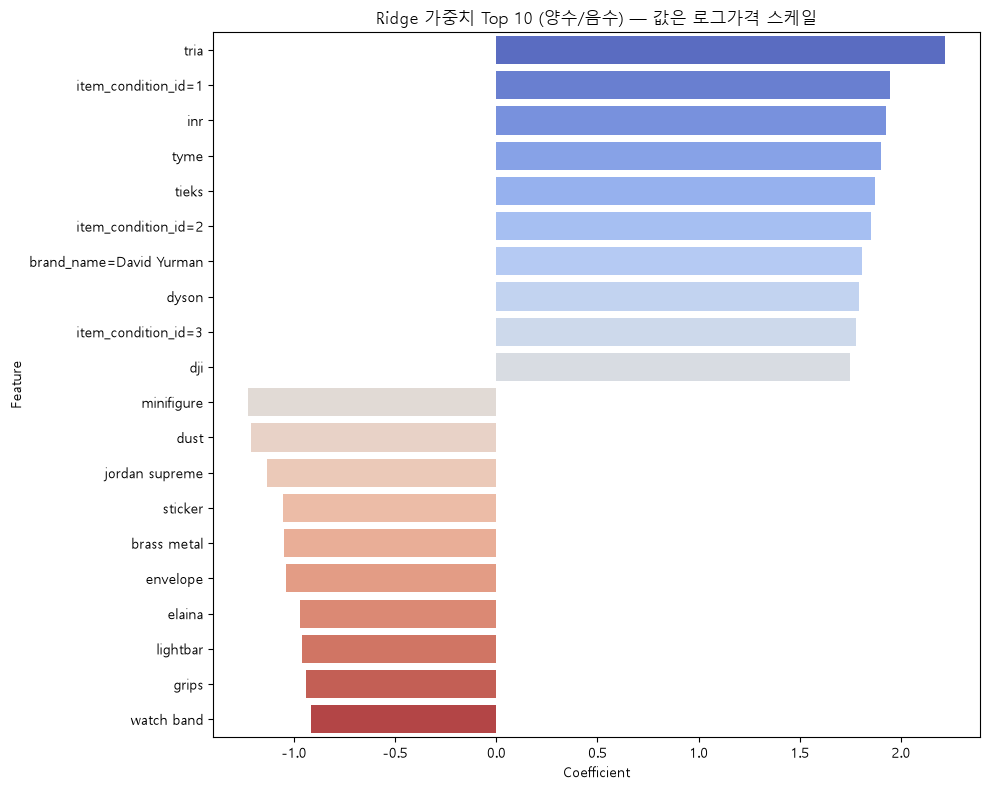

가장 가격을 올리는 피처:
                Feature  Coefficient
                   tria     2.218854
    item_condition_id=1     1.948064
                    inr     1.925994
                   tyme     1.901403
                  tieks     1.872204
    item_condition_id=2     1.853665
brand_name=David Yurman     1.807978
                  dyson     1.791794
    item_condition_id=3     1.776095
                    dji     1.746969

가장 가격을 내리는 피처:
       Feature  Coefficient
    minifigure    -1.227651
          dust    -1.211154
jordan supreme    -1.133481
       sticker    -1.053653
   brass metal    -1.049039
      envelope    -1.038848
        elaina    -0.970289
      lightbar    -0.959939
         grips    -0.940973
    watch band    -0.916448


In [41]:
# Ridge 모델 피처 가중치 확인 (TF-IDF + 원-핫 인코딩 전체 피처 대상)
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelBinarizer

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

CACHE = globals().get('CACHE', r"C:\big21\ml-dev\chap08\cache")

# --- 1. TF-IDF 단어 목록: 메모리의 vectorizer > 캐시 json > 2개만 1회 재적합 ---
_vocab_path = f"{CACHE}/tfidf_vocab.json"
if 'cnt_vec' in globals() and 'tfidf_descp' in globals():
    _name_terms = list(cnt_vec.get_feature_names_out())
    _desc_terms = list(tfidf_descp.get_feature_names_out())
elif os.path.exists(_vocab_path):
    with open(_vocab_path, encoding='utf-8') as _f:
        _v = json.load(_f)
    _name_terms, _desc_terms = _v['name'], _v['desc']
else:
    print('TF-IDF 단어목록 캐시 없음 → name/description 벡터라이저 2개만 재적합 (약 3~5분, 최초 1회)')
    _cv = TfidfVectorizer(max_features=50000, ngram_range=(1, 1),
                          stop_words='english').fit(mercari_df['name'])
    _td = TfidfVectorizer(max_features=50000, ngram_range=(1, 2),
                          stop_words='english').fit(mercari_df['item_description'])
    _name_terms = list(_cv.get_feature_names_out())
    _desc_terms = list(_td.get_feature_names_out())
    with open(_vocab_path, 'w', encoding='utf-8') as _f:
        json.dump({'name': _name_terms, 'desc': _desc_terms}, _f, ensure_ascii=False)
    print('  → 캐시 저장:', _vocab_path)

# --- 2. 원-핫 블록 이름: 캐시된 X_* 행렬 폭에 맞춰 재구성 (이진 컬럼은 1개짜리) ---
def _onehot_names(col, sp_block):
    cls = LabelBinarizer(sparse_output=True).fit(mercari_df[col]).classes_
    if sp_block.shape[1] == 1 and len(cls) == 2:
        return [f'{col}={cls[1]}']
    return [f'{col}={c}' for c in cls]

# X_all 컬럼 순서: (X_descp, X_name, X_brand, X_item_cond_id, X_shipping, X_cat_dae, X_cat_jung, X_cat_so)
feature_names = (
    list(_desc_terms) + list(_name_terms)
    + _onehot_names('brand_name',        X_brand)
    + _onehot_names('item_condition_id', X_item_cond_id)
    + _onehot_names('shipping',          X_shipping)
    + _onehot_names('cat_dae',           X_cat_dae)
    + _onehot_names('cat_jung',          X_cat_jung)
    + _onehot_names('cat_so',            X_cat_so)
)

# --- 3. Ridge 가중치와 매핑 (best_ridge: c9596ceb 셀에서 X_all 기준 학습, fit_intercept=False) ---
ridge_coefs = best_ridge.coef_
assert len(feature_names) == len(ridge_coefs), (len(feature_names), len(ridge_coefs))
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': ridge_coefs})

top_positive = coef_df.sort_values('Coefficient', ascending=False).head(10)
top_negative = coef_df.sort_values('Coefficient', ascending=True).head(10)
visual_df = pd.concat([top_positive, top_negative])

# --- 4. 시각화 (값은 로그가격 스케일) ---
plt.figure(figsize=(10, 8))
sns.barplot(x='Coefficient', y='Feature', data=visual_df, palette='coolwarm')
plt.title('Ridge 가중치 Top 10 (양수/음수) — 값은 로그가격 스케일')
plt.tight_layout()
plt.show()

print('가장 가격을 올리는 피처:')
print(top_positive.to_string(index=False))
print('\n가장 가격을 내리는 피처:')
print(top_negative.to_string(index=False))


---

## 최종 요약

| 모델 (test 홀드아웃) | train | valid | test RMSLE |
|---|---|---|---|
| 베이스라인 · 평균가 예측 | – | – | 0.7489 |
| Ridge (α=3, lsqr) | 0.4407 | 0.4699 | **0.4683** |
| LightGBM (HyperOpt tuned, n_est 207) | 0.4367 | 0.4605 | **0.4596** |
| **Ridge + LightGBM 앙상블 (w=0.4 / 0.6)** | – | 0.4530 | **0.4517** |

- 베이스라인 대비 RMSLE 0.7489 → 0.4517 (약 −40%). valid ≈ test 로 과적합 없음.
- 텍스트 제외 실험: name 제외 0.5104 · description 제외 0.5015 · 둘 다 0.4684 → 상품명이 가장 중요.
- RandomForest·XGBoost 는 설계행렬 1,482,535 × 105,812 희소에서 학습 비용 과다(커널 OOM)로 제외.
- 가격 구간별: 0–50(전체의 71%)에서 잘 맞고, 저가는 과대·고가는 급격히 과소예측.
